In [1]:
#dataset = https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction

#importing libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
#downloading dataset:
kagglehub.dataset_download('rikdifos/credit-card-approval-prediction')

100%|██████████| 5.32M/5.32M [00:08<00:00, 681kB/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\rikdifos\\credit-card-approval-prediction\\versions\\3'

In [2]:
#importing dataset:
application_record = pd.read_csv(r'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\rikdifos\\credit-card-approval-prediction\\versions\\3\application_record.csv')
credit_record = pd.read_csv(r'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\rikdifos\\credit-card-approval-prediction\\versions\\3\credit_record.csv')

In [7]:
#joining these 2 separate datasets into 1:
df = application_record.merge(credit_record, how = 'left', on = 'ID')
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0.0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1.0,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2.0,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3.0,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4.0,C


In [9]:
#drop unnecessary column like ID:
df = df.drop(columns = ['ID'])
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0.0,C
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1.0,C
2,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2.0,C
3,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3.0,C
4,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4.0,C


In [28]:
#now fixing the rest of the dataset:
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})
df = pd.get_dummies(df, columns = ['NAME_INCOME_TYPE'], drop_first = True)
df = pd.get_dummies(df, columns = ['NAME_EDUCATION_TYPE'], drop_first = True)
df = pd.get_dummies(df, columns = ['NAME_FAMILY_STATUS'], drop_first = True)
df = pd.get_dummies(df, columns = ['NAME_HOUSING_TYPE'], drop_first = True)

#occupation_type has nan so we will fill it with unknown first:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')
df = pd.get_dummies(df, columns = ['OCCUPATION_TYPE'], drop_first = True)
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,0,1,1,0,427500.0,-12005,-4542,1,1,0,...,False,False,False,False,False,False,False,False,True,False
1,0,1,1,0,427500.0,-12005,-4542,1,1,0,...,False,False,False,False,False,False,False,False,True,False
2,0,1,1,0,427500.0,-12005,-4542,1,1,0,...,False,False,False,False,False,False,False,False,True,False
3,0,1,1,0,427500.0,-12005,-4542,1,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,1,1,0,427500.0,-12005,-4542,1,1,0,...,False,False,False,False,False,False,False,False,True,False


In [33]:
#we fixed features now as there is no target so we will create a new column called approved and put it in there and remove status later on:
df['APPROVED'] = df['STATUS'].apply(lambda x: 0 if x in ['1', '2', '3', '4', '5'] else 1)

#dropping status cuz we dont need it now:
df = df.drop(columns = ['STATUS'])

In [34]:
#our dataset is fixed now defining our features and target:
x = df.drop(columns = ['APPROVED'])
y = df['APPROVED']

In [49]:
#splitting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [37]:
#making an ai model:
model = LogisticRegression(max_iter = 5000, class_weight = 'balanced')

In [47]:
#training ai model:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [52]:
#testing ai model based on testing data:
predictions = model.predict(x_test)

In [54]:
#evaluating ai model:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.02      0.52      0.04      3493
           1       0.99      0.59      0.74    229866

    accuracy                           0.59    233359
   macro avg       0.50      0.55      0.39    233359
weighted avg       0.97      0.59      0.73    233359



<Axes: >

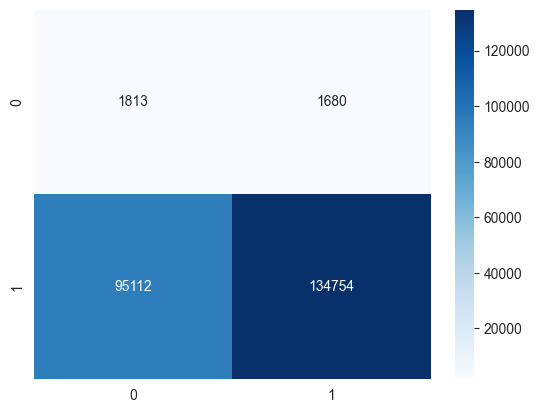

In [58]:
sns.heatmap(confusion_matrix(y_test, predictions), annot = True, fmt = 'd', cmap = 'Blues')